# General plot thingy

In [2]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.special import airy, jv, jvp
import subprocess

plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "pgf.texsystem": "pdflatex",
        "pgf.rcfonts": False,
        "font.size": 12,
    }
)

def done():
  subprocess.run(["notify-send", "-u", "low","-t", "1000", "Done", "Cell finished"])
  subprocess.run(["espeak","-a", "30","done"])
  
done()

# Algo for Computing $F$

## Naive algorithm

In [ ]:
N = 50          # chain length
s = 1           # sender site
r = N           # receiver site
J = 1/2

F_vals = []
max_F  = []
t_max = []
g_max = []

t = np.linspace(0, 4000/J, int(12*4000/J))
N_vals = np.arange(2,3)
# t = sp.symbols('t', real=True)

def a_m(m, N):
    if m == 1:
        return 1 / sp.sqrt(N)
    return sp.sqrt(2 / N)

for N in N_vals:
    gN = 0
    r = N
    for m in range(1, N + 1):
        am = a_m(m, N)
        phase = sp.exp(-4 * J * sp.I * t * (1 - sp.cos(sp.pi * (m - 1) / N)) )
        cos_r = sp.cos(sp.pi * (m - 1) * (2 * r - 1) / (2 * N) )
        cos_s = sp.cos(sp.pi * (m - 1) * (2 * s - 1) / (2 * N) )
        gN += am**2 * phase * cos_r * cos_s
    
    gN_func = sp.lambdify(t, gN, modules='numpy')
    gv = gN_func(t)
    mag = np.abs(gv)
    F_vals = 0.5 + mag / 3 + mag**2 / 6
    idx = np.argmax(F_vals)
    max_F.append(F_vals[idx])
    t_max.append(t[idx])
    print("Computed N  = ", N, "max F = ", F_vals[idx] )

## Optimized matrix form, still inefficient for large $N$

In [ ]:
J = 1/2

F_vals = []
max_F  = []
t_max = []
g_max = []
F_all = []
g_val = []

N_low = 30
# N_vals = np.arange(N_low,N_low*4,)
N_vals = np.arange(N_low,N_low+1)

for N in N_vals:
    tc =(N) /(4*J) 
    # tc =10 
    t = np.linspace(0*tc, tc * 3, int(2 * 1e4))
    m = np.arange(1, N + 1)
    # J = np.sqrt(m*(N-m))
    
    am2 = np.where(m == 1, 1/N, 2/N)
    # k = 
    E = 4 * J * (1 - np.cos(np.pi * (m - 1) / N))
    cos_s = np.cos(np.pi * (m - 1) / (2*N))
    cos_r = np.cos(np.pi * (m - 1) * (2 * N - 1) / (2*N))
    c_m = am2 * cos_s * cos_r
    phase = np.exp(-1j * np.outer(E, t))
    gN = phase.T @ c_m
    g_val.append(gN)
    
    mag = np.abs(gN)
    F = 0.5 + mag/3 + mag**2/6
    F_all.append(F)
    idx = np.argmax(F)
    max_F.append(F[idx])
    t_max.append(t[idx])

    print(f"`Computed N = {N}, max F = {F[idx]:.4f} at t = {t[idx]:.4f} with tc = {tc:.4f}` \n")

plt.figure(figsize=(10, 5))
plt.xlabel(r'$t$')
plt.ylabel(r'$F$')
plt.title(rf'Time evolution of fidelity at $N$ = {N_low}')
t_left  = tc * 0.8
t_right = tc * 1.2
tc1  = np.searchsorted(t, t_left)
tc2 = np.searchsorted(t, t_right)
plt.plot(t[tc1:tc2], F_all[0][tc1:tc2])
plt.plot(t, F_all[0])
plt.scatter(t_max,max_F)
plt.axvline(x=tc, linestyle='--',color='black',label=rf"$t_c = $ {tc}")
plt.legend()


`Computed N = 80, max F = 0.6196 at t = 41.7501 with tc = 40.0000`

`Computed N = 100, max F = 0.6120 at t = 152.3576 with tc = 50.0000` 

`Computed N = 1000, max F = 0.5479 at t = 504.0252 with tc = 500.0000`

`Computed N = 2000, max F = 0.5376 at t = 1005.0503 with tc = 1000.0000`

`...`

`Computed N = 8000, max F = 0.5232 at t = 4008.2004 with tc = 4000.0000`

`Computed N = 9000, max F = 0.5223 at t = 4508.5504 with tc = 4500.0000`

`Computed N = 10000, max F = 0.5215 at t = 5008.7504 with tc = 5000.0000`

## Large $N$ approx using Bessel representation

In [ ]:
J = 1/2

F_vals = []
max_F  = []
t_max = []
g_max = []

# N_low = 1e12

N_vals = np.arange(N_low,N_low+1)
N_vals = [1e2,1e3,1e4,1e5,1e6]

for N in N_vals:
    gN = 1.3499 * N**(-1/3)
    tc =(N) /(4*J) 
    mag = np.abs(gN)
    F = 0.5 + mag/3 + mag**2/6
    max_F.append(np.abs(gN))

    print(f"`Computed N = 1e{int(np.log10(N))}, max F = {F:.4f} at t = {(N+0.8089*N**(1/3))/(4*J)} with tc = {tc:.4f}`\n")

## Saddle point approx

### Saddle Point Visualization 

Normal plot of these integrand
\begin{equation*}
    g_N = \frac{2}{\pi} \int_{0} ^{\pi} dk\; \cos^2 (k/2) \exp \left[i \left\{Nk - 4Jt (1-\cos k)  \right\}  \right]
\end{equation*}

In [ ]:
N = 1.5*1e3
J = 1/4
tc = N / (4*J)

t1 = tc * 0.8
t2 = tc
t3 = tc * 1.2
t_vals = [t1,t2,t3]

k = np.linspace(0, np.pi, int(1e5))

F = []
k0 = []

for i, t in enumerate(t_vals):
    phase = N * k - 4 * J * t * (1 - np.cos(k))
    F.append(np.cos(k/2)**2 * np.exp(1j * phase))
    k0.append(np.arcsin(tc/t)) 
k02 = np.pi - k0[2]

fig, ax = plt.subplots(3,1, figsize=(10, 8))

for i in range(len(t_vals)):
  ax[i].plot(k,np.real(F[i]),label=r"$\Re f(k)$")
  ax[i].plot(k,np.imag(F[i]),label=r"$\Im f(k)$")
  ax[i].axvline(x=k0[i], linestyle='--',color='black')
  ax[i].set_yticks([])
  ax[i].set_xlim(0, np.pi)
  ax[i].set_ylim(-1, 1)
  subt = ["t<t_c", "t=t_c", "t_c<t"]
  ax[i].text(
      1.05, 0.5, rf"${subt[i]}$",
      transform=ax[i].transAxes,
      ha="left"
  )
  ax[i].set_xticks([])
  ax[i].set_xticklabels([])
ax[2].axvline(x=k02, linestyle='--',color='black',label=rf"$k_0$")
ticks = np.arange(0,np.pi+1e-1, np.pi/4)
labels_ticks = [r"$0$", r"${\pi}/{4}$", r"${\pi}/{2}$",r"${3\pi}/{4}$", r"$\pi$"]
ax[2].set_xticks(ticks)
ax[2].set_xticklabels(labels_ticks)

handles, labels = ax[2].get_legend_handles_labels()
fig.legend(handles, labels)
plt.tight_layout()

plt.savefig("plot_F_vs_k.pgf")
# tikzplotlib.save("plot_F_vs_k.tex")
# plt.show()

Plot around $k_0$

In [ ]:
t3 = tc * 1.2
k0 = np.arcsin(N/(4*J*t)) 
k = np.linspace(k0*0.6, k0*1.4,int(1e4))

phase = N * k - 4 * J * t * (1 - np.cos(k))
fr = np.cos(k/2)**2*np.cos(phase)
fi = np.cos(k/2)**2*np.sin(phase)

plt.plot(k,fr, label=r"$\Re f(k)$")
plt.plot(k, fi, label=r"$\Im f(k)$")
plt.axvline(x=k0, linestyle='--',color='black',label=rf"$k_0$ = {k0:.2f}")

plt.legend()

Contour plot (unfinished)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 10
J = 1/2
tc = N / (4 * J)
t = (
  tc
  *0.8
)

# Grid
x = np.linspace(1e-4,2* np.pi, 1000)
y = np.linspace(1e-4,0.5* np.pi, 100)

X, Y = np.meshgrid(x, y)

# Complex variable
Z = X + 1j * Y


# Function
F =np.cos(Z/2)**2 *np.exp( N*Z -4*J*t*(1-np.cos(Z)))

# Quantity to visualize
U = np.log10(np.abs(F))

plt.contourf(X, Y, U, levels=100)
plt.colorbar(label=r"$\log_{10}|F|$")

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("Contour Plot")


x = np.linspace(0*np.pi,2*np.pi,int(1e4))
y = np.arccosh((tc/t) * (np.pi/2 - x) / np.cos(x))
plt.plot(x, y, label=r"Contour")

x0 = np.pi / 2
y0 = np.arccosh((tc/t) )
plt.scatter(x0, y0, label=rf"$k_0=${x0:.2f} + i{y0:.2f}", color="red")

# plt.xlim(0, 2*np.pi)
plt.ylim(0, 0.5*np.pi)
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 10
J = 1/2
tc = N / (4 * J)
t = (
  tc
  # *0.8
  * (1.2)
)

# Grid
# x0 = np.pi/2
# yo = np.arccosh((tc/t)*np.pi/(2*np.sin(np.pi/2)))
# k0 = np.pi/2 +  1j*y0
# k = np.linspace(0, np.pi, int(1e4))
k0 = np.arcsin(tc/t) 
s = np.linspace(0, np.pi, int(1e4))   # parameter
Z = s * k0 

# F =np.cos(Z/2)**2 *np.exp( N*Z -4*J*t*(1-np.cos(Z)))

phase = N * Z - 4 * J * t * (1 - np.cos(Z))
F = np.cos(Z/2)**2*np.exp(1j*phase)

plt.plot(np.abs(s)  ,np.real(F), label=r"$\Re f(k)$", )
# plt.plot(s  ,np.imag_num_num(F), label=r"$\Im f(k)$", )
# plt.plot(k , fi , label=r"$\Im f(k)$",)
# plt.axvline(x=k0, linestyle='--',color='black',label=r"$k_0$")
# plt.axvline(x=np.pi - k0, linestyle='--',color='black',label=r"$k_0$")
plt.legend()


plt.legend()
plt.show()

### Mixed regime

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

J = 1/2

F_vals = []
max_F  = []
t_max = []
g_max = []
F_all = []
g_val = []

N_low = 80
N_vals = np.arange(N_low, N_low + 1)

for N in N_vals:
    tc = (N) / (4 * J) 
    t = np.linspace(0*tc, tc * 2, int(2 * 1e4))
    gN = np.zeros_like(t, dtype=complex)

    threshold = 2 * ((2 * J * tc) ** (1/3)) / (4 * J) 
    mask_airy = np.abs(t - tc) <= threshold
    t_mask_bessel = t[mask_airy]
    mask_l = t < (tc - threshold)
    t_mask_l = t[mask_l]    
    mask_gauss = t > (tc + threshold)
    t_mask_gauss = t[mask_gauss]
    # t_mask_airy = t

    amplitude_factor = np.sqrt(2 / np.pi) * (4 * J * t_mask_l - 1j * np.sqrt(N**2 - (4 * J * t_mask_l)**2)) / (4 * J * t_mask_l * (N**2 - (4 * J * t_mask_l)**2)**(1/4))
    oscillatory_phase = np.exp(1j * ((np.pi * N / 2) - 4 * J * t_mask_l))
    decay_factor = np.exp(-N * np.arccosh(N / (4 * J * t_mask_l)) + np.sqrt(N**2 - (4 * J * t_mask_l)**2))
    gN[mask_l] = amplitude_factor * oscillatory_phase * decay_factor

    airy_arg = 4 * J * (tc - t[mask_airy]) * ((2/N) ** (1/3))
    ai_val = airy(airy_arg)[0]
    prefactor = ((16 / N) ** (1/3))
    phase = np.exp(1j * ((np.pi * N / 2) - 4 * J * t[mask_airy]))
    gN[mask_airy] = prefactor * phase * ai_val


    arg = N / (4 * J * t_mask_gauss)
    arg = np.clip(arg, -1.0, 1.0)
    k1 = np.arcsin(arg)
    k2 = np.pi - k1
    phase_1 = N * k1 - 4 * J * t_mask_gauss * (1 - np.cos(k1))
    phase_2 = N * k2 - 4 * J * t_mask_gauss * (1 - np.cos(k2))
    gN_a = np.sqrt(2 *  np.cos(k1/2)**4/ (np.pi * J * t_mask_gauss * np.abs(np.cos(k1)))) * np.exp(1j * (phase_1 - np.pi / 4))
    gN_b = np.sqrt(2 *  np.cos(k2/2)**4/ (np.pi * J * t_mask_gauss * np.abs(np.cos(k2)))) * np.exp(1j * (phase_2 + np.pi / 4))
    gN[mask_gauss] = gN_a + gN_b
    
    mag = np.abs(gN)
    F = 0.5 + mag/3 + mag**2/6
    F_all.append(F)
    idx = np.argmax(F)
    max_F.append(F[idx])
    t_max.append(t[idx])

    print(f"`Computed N = {N}, max F = {F[idx]:.4f} at t = {t[idx]} with tc = {tc:.4f}`\n")

plt.figure(figsize=(10, 5))
plt.xlabel(r'$t$')
plt.ylabel(r'$F$')
plt.title(rf'Time evolution of fidelity at $N$ = {N_low}')
plt.plot(t, F_all[0])
plt.axvline(x=tc, linestyle='--', color='black', label=rf"$t_c = $ {tc}")
plt.legend()
plt.show()

`Computed N = 80, max F = 0.6509 at t = 0.0000 with tc = 40.0000`

`Computed N = 1000, max F = 0.5378 at t = 0.0000 with tc = 500.0000`

`Computed N = 2000, max F = 0.5263 at t = 0.0000 with tc = 1000.0000`

`Computed N = 3000, max F = 0.5213 at t = 0.0000 with tc = 1500.0000`

`Computed N = 4000, max F = 0.5184 at t = 0.0000 with tc = 2000.0000`

`Computed N = 5000, max F = 0.5164 at t = 0.0000 with tc = 2500.0000`

`Computed N = 6000, max F = 0.5150 at t = 0.0000 with tc = 3000.0000`

`Computed N = 7000, max F = 0.5138 at t = 0.0000 with tc = 3500.0000`

`Computed N = 8000, max F = 0.5129 at t = 0.0000 with tc = 4000.0000`

`Computed N = 9000, max F = 0.5122 at t = 0.0000 with tc = 4500.0000`


## Bessel function

In [ ]:
import numpy as np
from scipy.special import jv, jvp

J = 1/2

F_vals = []
max_F  = []
t_max = []
g_max = []
F_all = []
g_val = []

N_low = 1e2
# N_vals = np.arange(N_low,N_low*10,1000)
N_vals = np.arange(N_low,N_low + 1)
# N_vals = [1e2,1e3,1e4,1e5,1e6]


for N in N_vals:
    tc =(N) /(4*J) 
    # tc =10
    # t = np.linspace((1-N_low**(-1/2))*tc, tc * (1+N_low**(-1/2)), int(2 * 1e4))
    t = np.linspace(0*tc, tc * 2, int(2 * 1e4))
    # t = np.linspace(0*tc, tc * 5, int(2 * 1e4))

    z = 4 * J * t
    kN = np.pi*(N-1)/N

    k2 = np.pi/2
    kN = np.pi*(N-1)/N
    gN = (
        # 1/N + (1/N) * (np.cos(k2)**2 * np.exp(1j*(N*k2-4*J*t*(1-np.cos(k2)))) +  (np.cos(kN)**2 * np.exp(1j*(N*kN-4*J*t*(1-np.cos(kN))))) ) +
        np.exp(1j* (N* np.pi / 2 - 4 * t))
        * (jv(N, z) - 1j * jvp(N, z, 1))
    )

    mag = np.abs(gN)
    F = 0.5 + mag/3 + mag**2/6
    F_all.append(F)
    idx = np.argmax(F)
    max_F.append(F[idx])
    t_max.append(t[idx])

    print(f"`Computed N = 1e{int(np.log10(N))}, max F = {F[idx]:.4f} at t = {t[idx]} with tc = {tc:.4f}`\n")

plt.figure(figsize=(10, 5))
plt.xlabel(r'$t$')
plt.ylabel(r'$F$')
plt.title(rf'Time evolution of fidelity at $N$ = {N_low}')
t_left  = tc * 0.8
t_right = tc * 1.2
tc1  = np.searchsorted(t, t_left)
tc2 = np.searchsorted(t, t_right)
# plt.plot(t[tc1:tc2], F_all[0][tc1:tc2])
plt.plot(t, F_all[0])
plt.scatter(t_max,max_F)
plt.axvline(x=tc, linestyle='--',color='black',label=rf"$k_0 = $ {tc}")
plt.legend()

`Computed N = 1e2, max F = 0.5516 at t = 51.88459422971148 with tc = 50.0000`

`Computed N = 1e3, max F = 0.5232 at t = 504.045202260113 with tc = 500.0000`

`Computed N = 1e4, max F = 0.5106 at t = 5008.750437521876 with tc = 5000.0000`

`Computed N = 1e5, max F = 0.5049 at t = 50018.50092504625 with tc = 50000.0000`

`Computed N = 1e6, max F = 0.5022 at t = 500045.0022501125 with tc = 500000.0000`


## Direct numerical integration

In [ ]:
import numpy as np
from scipy.integrate import quad

J = 1/2

F_vals = []
max_F  = []
t_max = []
g_max = []
F_all = []
g_val = []

N_low = 100
# N_vals = np.arange(N_low,N_low*10,1000)
N_vals = np.arange(N_low,N_low + 1)
# N_vals = [1e2,1e3,1e4,1e5]

def integrand(k, N, J, t_scalar):
    phase = N * k - 4 * J * t_scalar * (1 - np.cos(k))
    amplitude = np.cos(k / 2)**2
    return amplitude * np.cos(phase), amplitude * np.sin(phase)

def compute_g_n_scalar(N, J, t_scalar):
    res_real, _ = quad(lambda k: integrand(k, N, J, t_scalar)[0], 0, np.pi, limit=100)
    res_imag, _ = quad(lambda k: integrand(k, N, J, t_scalar)[1], 0, np.pi, limit=100)
    return (1 / np.pi) * (res_real + 1j * res_imag)

# Vectorize the scalar function to handle the array 't'
v_compute_g_n = np.vectorize(compute_g_n_scalar, excluded=['N', 'J'])
  

for N in N_vals:
    tc =(N) /(4*J) 
    t = np.linspace(0.9*tc, tc * 1.1, int(2 * 1e3))
    
    gN = v_compute_g_n(N, J, t)

    mag = np.abs(gN)
    F = 0.5 + mag/3 + mag**2/6
    F_all.append(F)
    idx = np.argmax(F)
    max_F.append(F[idx])
    t_max.append(t[idx])

    print(f"`Computed N = {N}, max F = {F[idx]:.4f} at t = {t[idx]} with tc = {tc:.4f}`\n")


plt.figure(figsize=(10, 5))
plt.xlabel(r'$t$')
plt.ylabel(r'$F$')
plt.title(rf'Time evolution of fidelity at $N$ = {N_low}')
t_left  = tc * 0.8
t_right = tc * 1.2
tc1  = np.searchsorted(t, t_left)
tc2 = np.searchsorted(t, t_right)
# plt.plot(t[tc1:tc2], F_all[0][tc1:tc2])
plt.plot(t, F_all[0])
plt.scatter(t_max[0],max_F[0])
plt.axvline(x=tc, linestyle='--',color='black',label=rf"$k_0 = $ {tc}")
plt.legend()


## Plot of max $F$ vs $N$ from these methods

In [ ]:
J = 1/2

F_vals_num = []
F_max_num  = []
F_max_airy  = []
F_vals_airy = []
F_max_bessel  = []
F_vals_bessel = []
t_max = []
g_max = []
F_all = []
g_val = []

N_low = 2
N_vals = np.arange(2,81)

for N in N_vals:
    tc =(N) /(4*J) 
    # t = np.linspace(0*tc, tc * 3, int(2 * 1e4))
    t = np.linspace(0*tc, 4000/J + tc * 3, int(5 * 1e4))
    # t = np.linspace(0*tc, 4000/J, int(2 * 1e4))
    gN_num = np.zeros_like(t, dtype=complex)
    gN_airy = np.zeros_like(t, dtype=complex)
    gN_bessel = np.zeros_like(t, dtype=complex)
    
    m = np.arange(1, N + 1)
    am2 = np.where(m == 1, 1/N, 2/N)
    k = np.pi * (m - 1) / N
    E = 4 * J * (1 - np.cos(k))
    cos_s = np.cos(np.pi * (m - 1) / (2*N))
    cos_r = np.cos(np.pi * (m - 1) * (2 * N - 1) / (2*N))
    c_m = am2 * cos_s * cos_r
    phase = np.exp(-1j * np.outer(E, t))
    gN_num = phase.T @ c_m
    
    mag_num = np.abs(gN_num)
    F_num = 0.5 + mag_num/3 + mag_num**2/6
    idx_num = np.argmax(F_num)
    F_max_num.append(F_num[idx_num])

    # airy_arg = 4 * J * (tc - t) * ((2/N) ** (1/3))
    # ai_val = airy(airy_arg)[0]
    # prefactor = ((16 / N) ** (1/3))
    # phase = np.exp(1j * ((np.pi * N / 2) - 4 * J * t))
    # gN_airy = prefactor * phase * ai_val

    # mag_airy = np.abs(gN_airy)
    # F_airy = 0.5 + mag_airy/3 + mag_airy**2/6
    # idx_airy = np.argmax(F_airy)
    # F_max_airy.append(F_airy[idx_airy])

    # z = 4 * J * t
    # k2 = np.pi/2
    # kN = np.pi*(N-1)/N
    # gN_bessel = (
    #     np.exp(1j* (N* np.pi / 2 - 4 * t))
    #     * (jv(N, z) - 1j * jvp(N, z, 1))
    # )
    
    # mag_bessel = np.abs(gN_bessel)
    # F_bessel = 0.5 + mag_bessel/3 + mag_bessel**2/6
    # idx_bessel = np.argmax(F_bessel)
    # F_max_bessel.append(F_bessel[idx_bessel])


    # print(f"at N = {N}, F num = {F_num[idx]:.2f} F airy= {F_airy[idx]:.2f}")
    print(N)


In [ ]:
F_max_airy_plot = np.array(F_max_airy)
N_vals = np.array(N_vals)

plt.figure(figsize=(10, 6))
# plt.xlabel(r'Chain Length $N$')
plt.ylabel(r'max $F$')
# plt.title('Maximum Fidelity vs Chain Length')
plt.plot(N_vals,F_max_airy_1000,label=r"Saddle", linewidth=3)
plt.plot(N_vals,F_max_bessel_1000,label=r"Bessel", linewidth=3)
plt.bar(N_vals,F_max_num_1000,label=r"Numeric",color="black")

y0 = 2/3
plt.axhline(y0, linestyle="--",label=rf"Classical limit $F=2/3$")

idx = np.argmin(np.abs(F_max_num_1000[0:96] - y0))
x0 = N_vals[idx]
plt.annotate(
    rf"$N = {N_vals[idx]}$",
    xy=(x0, y0),            
    xytext=(x0 + 5, y0+0.02),    
    color="blue"
)


plt.plot(x0, y0, "o")
plt.xlim(0,1000)
plt.ylim(0,1)
plt.legend()

# plt.savefig("plot.png")
plt.savefig("plot_FvsN_tmore.pgf")

In [ ]:
# np.save("F_max_airy_1000.npy", F_max_airy_1000)
# np.save("F_max_bessel_1000.npy", F_max_bessel_1000)
# np.save("F_max_num_1000.npy", F_max_num_1000)

F_max_airy_1000 = np.load("F_max_airy_1000.npy")
F_max_bessel_1000 = np.load("F_max_bessel_1000.npy")
F_max_num_1000 = np.load("F_max_num_1000.npy")

In [ ]:
# N_low = 2
N_vals = np.arange(2,1001,1)

# F_max_airy_low = F_max_airy
# F_max_bessel_low = F_max_bessel
# F_max_num_low = F_max_num 

# F_max_airy_more = F_max_airy
# F_max_bessel_more = F_max_bessel
# F_max_num_more = F_max_num 

# F_max_airy = np.load("F_max_airy.npy")
# F_max_bessel = np.load("F_max_bessel.npy")
# F_max_num = np.load("F_max_num.npy")

# arr1 = np.array(F_max_num_low)   
# arr2 = np.array(F_max_num_more)   

# F_max_airy_1000 = np.concatenate((arr1, arr2), axis=0)
# F_max_bessel_1000 = np.concatenate((arr1, arr2), axis=0)
# F_max_num_1000 = np.concatenate((arr1, arr2), axis=0)

## Other plot

Plot the amplitude in terms of $k$
\begin{equation*}
  g_N  = \sum_{k }  \exp \left[ -i4Jt(1 - \cos k) \right] \cos (k(N-1/2)) \cos (k/2)\\
\end{equation*}


In [ ]:
t0 = 1.0
N_current = 80
J = 1/2
g_val = []
k_range = np.linspace(0,2*np.pi,1000)

for k in k_range:
    am = 1
    phase = np.exp(-4j * J * t0 * (1 - np.cos(k)))
    cos_r = np.cos(k*(N_current - 1/2))
    cos_s = np.cos(k/2)
    g_val.append(am * phase * cos_s * cos_r)

plt.plot(k_range, np.real(g_val), label="real")
plt.plot(k_range, np.imag(g_val), label="imag")
# plt.plot(k_range, np.abs(g_val), label="abs")
plt.legend()

# Long Range Coupling

### Few Functions

In [3]:
def HxLong(N, C, a, nu, B,alp):
    H = np.zeros((N, N), dtype=float)

    def J(i, j):
        if i == j:
            return 0.0

        r = float(abs(i - j)) * float(a)
        return C / r**nu

    for i in range(N):
        for j in range(N):
            if i != j:
                H[i, j] = -2 * J(i, j)
            else:
                H[i, j] = 2 * sum(J(i, k) for k in range(N) if k != i) - 2 * B

    return H

def HxDHLong(N, C, a, nu, B, alph):
    H = np.zeros((N, N), dtype=float)

    def J(i, j):
        if i == j:
            return 0.0

        if i in (1, N-2) or j in (1, N-2):
            return alph
        r = float(abs(i - j)) * float(a)
        return C / r**nu

    for i in range(N):
        for j in range(N):
            if i != j:
                H[i, j] = -2 * J(i, j)
            else:
                H[i, j] = 2 * sum(J(i, k) for k in range(N) if k != i) - 2 * B
    return H


def HxDHLong2(N, C, a, nu, B, alph):
    H = np.zeros((N, N), dtype=float)

    def J(i, j):
        if i == j:
            return 0.0

        if (i, j) in {(0,1), (1,0), (N-1,N-2), (N-2,N-1)}:
            return alph
        r = float(abs(i - j)) * float(a)
        return C / r**nu

    for i in range(N):
        for j in range(N):
            if i != j:
                H[i, j] = -2 * J(i, j)
            else:
                H[i, j] = 2 * sum(J(i, k) for k in range(N) if k != i) - 2 * B
    return H

def HxShort(N, C, a, nu, B,alp):
    H = np.zeros((N, N), dtype=float)
    def J(i, j):
        if i == j:
            return 0.0
        if abs(i - j) == 1:
            return C / a**nu 
        return 0.0
    for i in range(N):
        for j in range(N):
            if i != j:
                H[i, j] = -2 * J(i, j)
            else:
                H[i, j] = 2 * sum(J(i, k) for k in range(N) if k != i) - 2 * B
    return H

def HxDHShort(N, C, a, nu, B, alp):
    H = np.zeros((N, N), dtype=float)
    def J(i, j):
        r = 1
        if (i, j) in {(0,1), (1,0), (1,2), (2,1), (N-3,N-2), (N-2,N-3), (N-1,N-2), (N-2,N-1)}:
            return alp
        if i == j:
            return 0.0
        if abs(i - j) <= r:
            return C / a**nu 
        return 0.0
    for i in range(N):
        for j in range(N):
            if i != j:
                H[i, j] = -2 * J(i, j)
            else:
                H[i, j] = 2 * sum(J(i, k) for k in range(N) if k != i) - 2 * B
    return H

def HxDHShort2(N, C, a, nu, B, alp):
    H = np.zeros((N, N), dtype=float)
    def J(i, j):
        r = 1
        if (i, j) in {(0,1), (1,0), (N-1,N-2), (N-2,N-1)}:
            return alp
        if i == j:
            return 0.0
        if abs(i - j) <= r:
            return C / a**nu 
        return 0.0
    for i in range(N):
        for j in range(N):
            if i != j:
                H[i, j] = -2 * J(i, j)
            else:
                H[i, j] = 2 * sum(J(i, k) for k in range(N) if k != i) - 2 * B
    return H


def HxRHShort(N, C, a, nu, B, alp):
    H = np.zeros((N, N), dtype=float)
    def J(i, j):
        r = 1
        if (i, j) in {(N-3,N-2), (N-2,N-3), (N-1,N-2), (N-2,N-1)}:
            return alp
        if i == j:
            return 0.0
        if abs(i - j) <= r:
            return C / a**nu 
        return 0.0
    for i in range(N):
        for j in range(N):
            if i != j:
                H[i, j] = -2 * J(i, j)
            else:
                H[i, j] = 2 * sum(J(i, k) for k in range(N) if k != i) - 2 * B
    return H

def HxSHShort2(N, C, a, nu, B, alp):
    H = np.zeros((N, N), dtype=float)
    def J(i, j):
        r = 1
        if (i, j) in {(0,1), (1,0), (1,2), (2,1)}:
            return alp
        if i == j:
            return 0.0
        if abs(i - j) <= r:
            return C / a**nu 
        return 0.0
    for i in range(N):
        for j in range(N):
            if i != j:
                H[i, j] = -2 * J(i, j)
            else:
                H[i, j] = 2 * sum(J(i, k) for k in range(N) if k != i) - 2 * B
    return H

def HxDipole(N, C, a, nu, B,alp):
    H = np.zeros((N, N), dtype=float)

    def J(i, j):
        if i == j:
            return 0.0
        r = float(abs(i - j)) * float(a)
        return C / r**nu

    J_total = sum(J(k, l) for k in range(N) for l in range(k+1, N))
    J_site = np.array([sum(J(i, k) for k in range(N) if k != i) for i in range(N)])
    for i in range(N):
        for j in range(N):
            if i != j:
                H[i, j] = -2 * J(i, j)
            else:
                H[i, i] = 3 * J_total -  4 * J_site[i] - 2 * B

    return H


def HxDHDipole(N, C, a, nu, B,alp):
    H = np.zeros((N, N), dtype=float)

    def J(i, j):
        if i == j:
            return 0.0

        if i in (1, N-2) or j in (1, N-2):
            return alp

        # return C / (a * abs(i - j))**nu
        r = float(abs(i - j)) * float(a)
        return C / r**nu

    for i in range(N):
        for j in range(N):
            if i != j:
                H[i, j] = -2 * J(i, j)

    J_total = sum(J(k, l) for k in range(N) for l in range(k+1, N))
    J_site = np.array([sum(J(i, k) for k in range(N) if k != i) for i in range(N)])
    for i in range(N):
        for j in range(N):
            if i != j:
                H[i, j] = -2 * J(i, j)
            else:
                H[i, i] = 3 * J_total -  4 * J_site[i] - 2 * B

    return H


def RemH(H):
    H[1, :] = 0
    H[:, 1] = 0
    H[N-2, :] = 0
    H[:, N-2] = 0
    return H

np.set_printoptions(precision=3, suppress=True)
# H = HxDH(20,1,1,200,1)

# print(H)
# print(HxDHLong2(6,1,1,5,0,0.01))
print(HxDHLong2(50,1,1,10,0,1e-9))
# print(Hx(6,1,1,100,0,0))
# print(HxDHShort(50,1,1,1,0,0))
# print(HxSHShort(5,1,1,1,0,0))
# print(HxRHShort(5,1,1,1,0,0))
# print(HxShort(6,1,1,1,0,0))
# print(np.allclose(Hx(10,1,1,80,0), Hx(10,1,1,80,0).T.conj()))

# evals, evecs = np.linalg.eigh(H)
# print(np.min(np.abs(evals)))
# print(np.max(np.abs(evals)))

[[ 0.002 -0.    -0.002 ... -0.    -0.    -0.   ]
 [-0.     2.002 -2.    ... -0.    -0.    -0.   ]
 [-0.002 -2.     4.004 ... -0.    -0.    -0.   ]
 ...
 [-0.    -0.    -0.    ...  4.004 -2.    -0.002]
 [-0.    -0.    -0.    ... -2.     2.002 -0.   ]
 [-0.    -0.    -0.    ... -0.002 -0.     0.002]]


In [4]:
def compalp(Hfunc, C, a,nu, B, alp):
    max_F_all = []
    max_F_nu = []
    for alp in alp:
        H = Hfunc(N, C, a, nu, B, alp)
        eigvals, eigvecs = np.linalg.eigh(H)
        V = eigvecs
        idx = np.argsort((eigvals))
        eigvals = eigvals[idx]
        t_approx = np.pi/np.abs(eigvals[1]-eigvals[2])
        # t_vals = np.linspace(0,3*t_approx,int(1e4))
        t_vals = np.linspace(0,3*1e6,int(1e4))
        ck = V[-1, :] * np.conj(V[0, :])
        phase = np.exp(-1j * np.outer(eigvals, t_vals))
        amp = ck @ phase

        F_t = np.abs(amp)**2 / 6 + np.abs(amp)/3 + 1/2
        max_F_nu.append(np.max(F_t))
    max_F_all.append(max_F_nu)
    return max_F_all


def comp(Hfunc, C, a,nu, B, alp):
    max_F_all = []
    max_F_nu = []
    for N in N_vals:
        # tc = np.pi * (N - 1)**5 / 2
        # tc = N / 4
        t_vals = np.linspace(0, 1e6, int(5 * 1e5))
        # t_vals = np.linspace(0, 4000+3*N/4, int(5 * 1e4))
        
        H = Hfunc(N, C, a, nu, B, alp)
        eigvals, eigvecs = np.linalg.eigh(H)
        V = eigvecs
        ck = V[-1, :] * np.conj(V[0, :])
        phase = np.exp(-1j * np.outer(eigvals, t_vals))
        amp = ck @ phase

        F_t = np.abs(amp)**2 / 6 + np.abs(amp)/3 + 1/2
        max_F_nu.append(np.max(F_t))
        print(N) 
    max_F_all.append(max_F_nu)
    return max_F_all


def compshort(Hfunc, C, a, B):
    max_F_all = []

    for nu in nu_vals:
        max_F_nu = []

        for N in N_vals:
            t_vals = np.linspace(0, 4000+3*N/(4*C), int(5 * 1e4))
            # t_vals = np.linspace(0, 4000, int(5 * 1e5))
            
            H = Hfunc(N, C, a, nu, B)
            eigvals, eigvecs = np.linalg.eigh(H)
            # eigvals, eigvecs = eigh(H, driver="evr")
            V = eigvecs
            ck = V[-1, :] * np.conj(V[0, :])
            phase = np.exp(-1j * np.outer(eigvals, t_vals))
            amp = ck @ phase

            F_t = np.abs(amp)**2 / 6 + np.abs(amp)/3 + 1/2
            max_F_nu.append(np.max(F_t))
            print(N) 
        max_F_all.append(max_F_nu)
    return max_F_all


def tcomp(Hfunc, C, a, nu, B, t,alp):
    max_F_all = []

    max_F_nu = []
    H = Hfunc(N, C, a, nu, B,alp)
    eigvals, eigvecs = np.linalg.eigh(H)
    V = eigvecs
    ck = V[-1, :] * np.conj(V[0, :])
    phase = np.exp(-1j * np.outer(eigvals, t_vals))
    amp = ck @ phase

    F_t = np.abs(amp)**2 / 6 + np.abs(amp)/3 + 1/2
    print(N) 
    return F_t

def tcompalt(Hfunc, C, a, nu, B, t,alp):
    max_F_all = []

    max_F_nu = []
    H = Hfunc(N, C, a, nu, B,alp)
    eigvals, eigvecs = np.linalg.eigh(H)
    V = eigvecs
    ck = V[-1, :] * np.conj(V[0, :])
    phase = np.exp(-1j * np.outer(eigvals, t_vals))
    amp = ck[1:3] @ phase[1:3, :]

    F_t = np.abs(amp)**2 / 6 + np.abs(amp)/3 + 1/2
    print(N) 
    return F_t

def tcompalt2(Hfunc, C, a, nu, B, t,alp):
    max_F_all = []

    max_F_nu = []
    H = Hfunc(N, C, a, nu, B,alp)
    eigvals, eigvecs = np.linalg.eigh(H)
    V = eigvecs
    ck = V[-1, :] * np.conj(V[0, :])
    phase = np.exp(-1j * np.outer(eigvals, t_vals))
    amp = ck @ phase - ck[1:3] @ phase[1:3, :]

    F_t = np.abs(amp)**2 / 6 + np.abs(amp)/3 + 1/2
    print(N) 
    return F_t


### $F$ vs $N$ for 100 $N$

#### Dipole

In [ ]:
C = 1
a = 1 
nu = 3
B = 1

N_vals = np.arange(2,100)
nu_vals = np.arange(3,4)

dipole_full = comp(HxDipole, C, a, B)
dipole_dh = comp(HxDHDipole, C, a, B)

done()

In [ ]:
plt.figure(figsize=(10, 6))
plt.xlabel(r'$F$')
plt.ylabel(r'$N$')

plt.scatter(N_vals, dipole_full[0], label=rf"Complete", marker="D",facecolor="none",color="black")
plt.plot(N_vals[0:], dipole_dh[0][0:], label=rf"Double-hole", )

plt.ylim(0.9 - 1e-2,1 + 1e-2)
plt.legend()

# plt.savefig("return0dipole.png")
print(dipole_dh[0][0:5])

#### Long range

In [ ]:
C = 1
a = 1 
nu = 10
# alp = [0, 1e-1,1e-2,1e-3,1e-4]
alp = [1e-2]
B = 0
N_vals = np.arange(2,100)
long_full = comp(HxLong, C, a,nu, B,0)
nu_vals = np.arange(nu,nu+1)

for alp in alp:

  long_dh = comp(HxDHLong, C, a, nu, B,alp)

  plt.figure(figsize=(10, 6))
  plt.xlabel(r'$N$')
  plt.ylabel(r'$F$')
  plt.bar(N_vals, long_full[0], label=rf"Complete",color="black", )
  plt.plot(N_vals, long_dh[0], label=rf"Double-hole", )
  plt.ylim(0.5 - 1e-2,1 + 1e-2)
  plt.tight_layout()
  plt.legend()
  # plt.savefig(f"zfig_FvsN_longv1_nu{nu}_alp_{alp}.png")
done()

In [ ]:
C = 1
a = 1 
nu = 10
# alp = [0,1e-1,1e-2,1e-3,1e-4]
alp = 1e-2
B = 0
N_vals = np.arange(3,80)
nu_vals = np.arange(nu,nu+1)

# long_full = comp(HxLong, C, a,nu, B,alp)

long_dh = comp(HxDHLong2, C, a,nu, B,alp)

plt.figure(figsize=(10, 6))
plt.xlabel(r'$N$')
plt.ylabel(r'$F$')

plt.scatter(N_vals, long_full[0], label=rf"Complete",color="black", marker="D",facecolor="none",)
plt.plot(N_vals, long_dh[0], label=rf"Double-hole", )
plt.title(rf'$F$ vs $N$, $\alpha = {alp}$')
plt.ylim(0.5,1 )
plt.tight_layout()
plt.legend()
# plt.savefig(f"zfig_FvsN_long2_nu{nu}_alp_{alp}.png")
done()

In [ ]:
C = 1
a = 1 
nu = 10
alp = np.linspace(0,100,int(1e2))
# alp = [1e-3]
B = 0
N = 50

long_dh = compalp(HxDHLong2, C, a,nu, B,alp,)

plt.figure(figsize=(10, 6))
plt.xlabel(r'$\alpha$')
plt.ylabel(r"$\langle F \rangle_{\max}$")

plt.plot(alp, long_dh[0],)
plt.ylim(0.5 - 1e-2,1 + 1e-2)
plt.tight_layout()
# plt.savefig("lr_Fvsalp_v2.png")
done()

#### Short range

In [ ]:
C = 1
a = 1 
nu = 10
alp = [0,1e-1,1e-2,1e-3,1e-4]
# alp = [1e-3]
B = 1
N_vals = np.arange(2,80)
nu_vals = np.arange(nu,nu+1)

short_full = comp(HxShort, C, a, B,alp)
for alp in alp:

  short_dh = comp(HxSHShort, C, a, B,alp)

  plt.figure(figsize=(10, 6))
  plt.xlabel(r'$N$')
  plt.ylabel(r'$F$')

  plt.scatter(N_vals, short_full[0], label=rf"Complete",color="black", marker="D",facecolor="none",)
  plt.plot(N_vals, short_dh[0], label=rf"Double-hole", )
  plt.title(rf'$F$ vs $N$, $\alpha = {alp}$')
  plt.ylim(0.5 - 1e-2,1 + 1e-2)
  plt.tight_layout()
  plt.legend()
  plt.savefig(f"zfig_FvsN_short_sender_hole_alp_{alp}.png")
done()

In [ ]:
C = 1
a = 1 
nu = 10
alp = [0,1e-1,1e-2,1e-3,1e-4]
# alp = [1e-3]
B = 1
N_vals = np.arange(2,80)
nu_vals = np.arange(nu,nu+1)

short_full = comp(HxShort, C, a, B,alp)
for alp in alp:

  short_dh = comp(HxRHShort, C, a, B,alp)

  plt.figure(figsize=(10, 6))
  plt.xlabel(r'$N$')
  plt.ylabel(r'$F$')

  plt.scatter(N_vals, short_full[0], label=rf"Complete",color="black", marker="D",facecolor="none",)
  plt.plot(N_vals, short_dh[0], label=rf"Double-hole", )
  plt.title(rf'$F$ vs $N$, $\alpha = {alp}$')
  plt.ylim(0.5 - 1e-2,1 + 1e-2)
  plt.tight_layout()
  plt.legend()
  plt.savefig(f"zfig_FvsN_short_receiver_hole_alp_{alp}.png")
done()

#### misc

In [ ]:
import numpy as np
from scipy.special import airy
import matplotlib.pyplot as plt

def HxLong(N, C, a, nu, B,alp):
    H = np.zeros((N, N), dtype=float)

    def J(i, j):
        if i == j:
            return 0.0

        r = float(abs(i - j)) * float(a)
        return C / r**nu

    for i in range(N):
        for j in range(N):
            if i != j:
                H[i, j] = -2 * J(i, j)
            else:
                H[i, j] = 2 * sum(J(i, k) for k in range(N) if k != i) - 2 * B

    return H

def comp(Hfunc, C, a,nu, B, alp):
    max_F_all = []
    max_F_nu = []
    for N in N_vals:
        tc = N / 4 
        t_vals = np.linspace(0, 10 *tc, int(5 * 1e4))
        
        H = Hfunc(N, C, a, nu, B, alp)
        eigvals, eigvecs = np.linalg.eigh(H)
        V = eigvecs
        ck = V[-1, :] * np.conj(V[0, :])
        phase = np.exp(-1j * np.outer(eigvals, t_vals))
        amp = ck @ phase

        F_t = np.abs(amp)**2 / 6 + np.abs(amp)/3 + 1/2
        max_F_nu.append(np.max(F_t))
        print(N) 
    max_F_all.append(max_F_nu)
    return max_F_all

C = 1
a = 1 
nu = 10
# alp = [0, 1e-1,1e-2,1e-3,1e-4]
alp = [0]
B = 0
J = 1
N_vals = np.arange(2,1001)

# F_max_lr = comp(HxLong, C, a,nu, B,alp)

# F_vals_num = []
# F_max_num  = []
# F_max_airy  = []
# F_vals_airy = []
# F_max_bessel  = []
# F_vals_bessel = []
# t_max = []
# g_max = []
# F_all = []
# g_val = []


# for N in N_vals:
#     tc =(N) /(4*J) 
#     t = np.linspace(0*tc,10 * tc, int(1e4))
#     gN_num = np.zeros_like(t, dtype=complex)
#     gN_airy = np.zeros_like(t, dtype=complex)
    
#     m = np.arange(1, N + 1)
#     am2 = np.where(m == 1, 1/N, 2/N)
#     k = np.pi * (m - 1) / N
#     E = 4 * J * (1 - np.cos(k))
#     cos_s = np.cos(np.pi * (m - 1) / (2*N))
#     cos_r = np.cos(np.pi * (m - 1) * (2 * N - 1) / (2*N))
#     c_m = am2 * cos_s * cos_r
#     phase = np.exp(-1j * np.outer(E, t))
#     gN_num = phase.T @ c_m
    
#     mag_num = np.abs(gN_num)
#     F_num = 0.5 + mag_num/3 + mag_num**2/6
#     idx_num = np.argmax(F_num)
#     F_max_num.append(F_num[idx_num])
        
#     airy_arg = 4 * J * (tc - t) * ((2/N) ** (1/3))
#     ai_val = airy(airy_arg)[0]
#     prefactor = ((16 / N) ** (1/3))
#     phase = np.exp(1j * ((np.pi * N / 2) - 4 * J * t))
#     gN_airy = prefactor * phase * ai_val

#     mag_airy = np.abs(gN_airy)
#     F_airy = 0.5 + mag_airy/3 + mag_airy**2/6
#     idx_airy = np.argmax(F_airy)
#     F_max_airy.append(F_airy[idx_airy])

# np.save("F_max_airy_1000.npy", F_max_airy)
# np.save("F_max_bessel_1000.npy", F_max_lr)
# np.save("F_max_num_1000.npy", F_max_num)

F_max_airy= np.load("F_max_airy_1000.npy")
F_max_lr = np.load("F_max_bessel_1000.npy")
F_max_num = np.load("F_max_num_1000.npy")

plt.xlim(0,1000)
plt.ylim(0.0,1 + 1e-2)

plt.plot(N_vals, F_max_airy, label=r"Saddle", color="blue")
plt.bar(N_vals, F_max_num, label=r"Numeric", color="black")
plt.scatter(
    N_vals,
    F_max_lr[0],
    label=rf"Complete",
    color="red",
    marker="D",
    facecolor="none",
    s=2
)

ax.set_xlabel(r"$N$")
ax.set_ylabel(r"$F_{\max}$")

plt.tight_layout()
plt.legend()

done()

In [ ]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    sharey=True,
    figsize=(12,6)
)

for ax in (ax1, ax2):
    ax.plot(N_vals, F_max_airy, color="blue",label=r"Saddle-Point")
    ax.bar(N_vals, F_max_num, color="black",label=r"Numeric Eigenvec")
    ax.scatter(
        N_vals,
        F_max_lr[0],
        color="red",
        marker="D",
        facecolors="none",
        label=r"LR Matrix Element",
        s=2,
    )

fig.supxlabel(r"$N$")
fig.supylabel(r"$\langle F \rangle_{\max}$")
plt.tight_layout()
plt.legend()
fig.subplots_adjust(wspace=0.08)
ax.set_ylim(0.5, 1 + 1e-2)
ax1.set_xlim(2, 100)
ax2.set_xlim(500, 1000)
plt.savefig("plot_FvsN_3_method.pgf")

### Time evolution for $N=50$

50
50
50
50


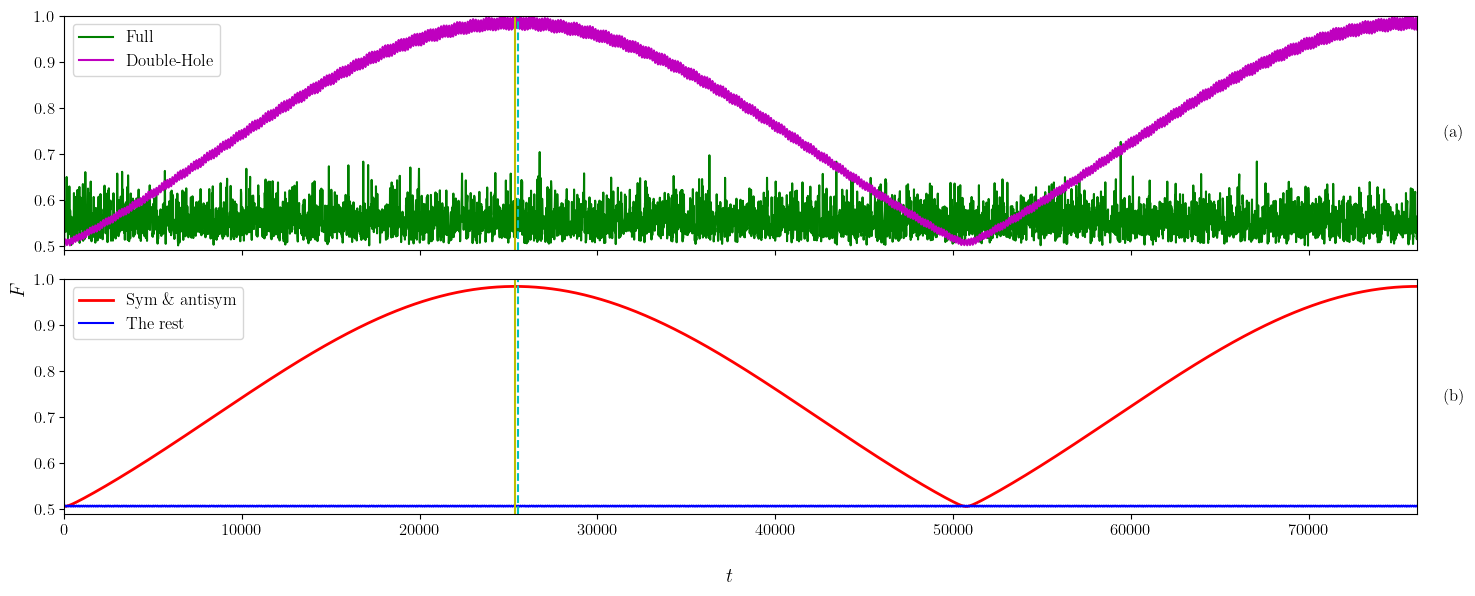

In [7]:
C = 1
a = 1 
nu = 10
B = 0
# alp= np.logspace(0, -3, 4)
alp =1e-2
N = 50

H = HxDHLong(N,C,a,nu,B,alp)
eigvals,_ = np.linalg.eigh(H)
idx = np.argsort((eigvals))
eigvals = eigvals[idx]
t_approx = np.pi/np.abs(eigvals[1]-eigvals[2])

t_vals = np.linspace(0,3*t_approx, int(5 * 1e3))
lr_dh_t = tcomp(HxDHLong, C, a,nu, B, t_vals,alp)
lr_dh1_t = tcompalt(HxDHLong, C, a,nu, B, t_vals,alp)
lr_dh2_t = tcompalt2(HxDHLong, C, a,nu, B, t_vals,alp)
lr_full_t = tcomp(HxLong, C, a,nu, B, t_vals,alp)

fig, ax = plt.subplots(2, 1,sharex=True,figsize=(15, 6))

fig.supxlabel(r"$t$")
fig.supylabel(r"$F$")

ax[0].plot(t_vals,lr_full_t, label="Full",color='g',)
ax[0].plot(t_vals,lr_dh_t, label="Double-Hole",color='m',)
ax[1].plot(t_vals,lr_dh1_t, label=r"Sym \& antisym",linewidth=2,color='red')
ax[1].plot(t_vals,lr_dh2_t, label="The rest",color='blue')
for i in range (2):
  ax[i].axvline(t_approx,linestyle="-",color='y')
  ax[i].axvline(t_vals[np.argmax(lr_dh_t[0:int(len(lr_dh_t)/2)])],linestyle="--",color='c')
  ax[i].legend()

  ax[i].set_ylim(0.5-1e-2,1)
plt.xlim(0,np.max(t_vals))

ax[0].text(
    1.02, 0.5, '(a)',
    transform=ax[0].transAxes,
    va='center',
    ha='left'
)

ax[1].text(
    1.02, 0.5, '(b)',
    transform=ax[1].transAxes,
    va='center',
    ha='left'
)

plt.tight_layout()
plt.savefig(f"tevol.pgf")
done()

50
50


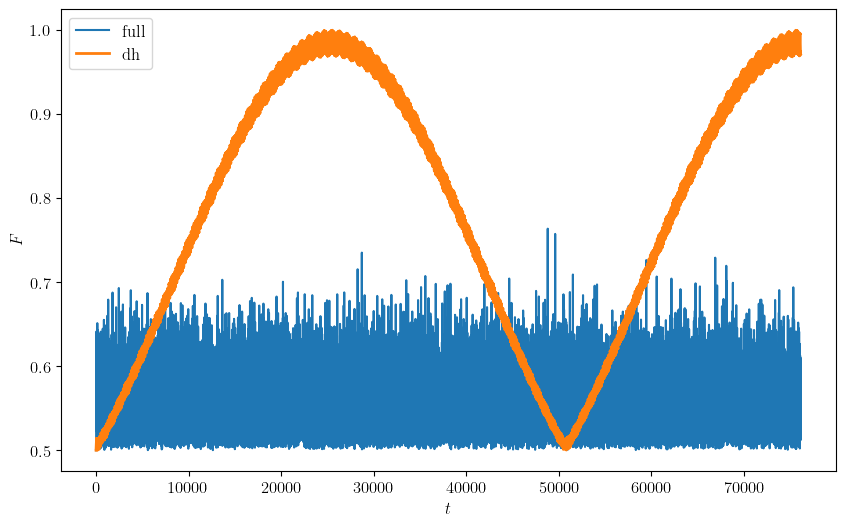

In [5]:
C = 1
a = 1 
nu = 10
B = 0
alp = 1e-2
N = 50


H = HxDHLong(N,C,a,nu,B,alp)
eigvals,_ = np.linalg.eigh(H)
idx = np.argsort((eigvals))
eigvals = eigvals[idx]
t_approx = np.pi/np.abs(eigvals[1]-eigvals[2])

t_vals = np.linspace(0,3*t_approx, int(5 * 1e4))
lr_dh_t = tcomp(HxDHLong, C, a,nu, B, t_vals,alp)
lr_full_t = tcomp(HxLong, C, a,nu, B, t_vals,alp)

plt.figure(figsize=(10, 6))
plt.xlabel(r'$t$')
plt.ylabel(r'$F$')

plt.plot(t_vals,lr_full_t, label="full")
plt.plot(t_vals,lr_dh_t, label="dh",linewidth=2)

t_dhmax = t_vals[np.argmax(lr_dh_t[0:int(len(lr_dh_t)/2)])]

plt.legend()
# plt.savefig(f"longv_tevol_nu{nu}_return_{alp:.0e}.png")
done()

### Eigenvalue

#### dipole

In [ ]:
C = 1
a = 1 
nu = 3
B = 1

N = 100
N_vals = np.arange(N,N+1)

H_dipole_dh = HxDHDipole(N,C,a,nu,B)
H_dipole_full = HxDipole(N,C,a,nu,B)

eigvals_dh, eigvecs_dh = np.linalg.eig(H_dipole_dh)
eigvals_full, eigvecs_full = np.linalg.eig(H_dipole_full)

idx = np.argsort(eigvals_dh)
eigvals_dh = eigvals_dh[idx]
# eigvals_dh = eigvals_dh - eigvals_dh.min()
eigvecs_dh = eigvecs_dh[:, idx]

idx2 = np.argsort(eigvals_full)
eigvals_full = eigvals_full[idx2]
# eigvals_full = eigvals_full - eigvals_full.min()
eigvecs_full = eigvecs_full[:, idx2]


idx_range = range(len(eigvals_dh)-10, len(eigvals_dh))
# idx_range = range(len(eigvals_dh))
fig, ax = plt.subplots(len(idx_range), 2, figsize=(10, 2*len(idx_range)))

for row, i in enumerate(idx_range):
    ax[row, 0].bar(
        np.arange(len(eigvecs_dh[:, i])),
        eigvecs_dh[:, i],
        color="black"
    )
    ax[row, 0].set_title(f"dh eigenvector {i}, $E={eigvals_dh[i]:.4f}$")

    ax[row, 1].bar(
        np.arange(len(eigvecs_full[:, i])),
        eigvecs_full[:, i],
        color="black"
    )
    ax[row, 1].set_title(f"full eigenvector {i}, $E={eigvals_full[i]:.4f}$")

plt.tight_layout()
# plt.savefig("zfig_dipole_evec_return0.0..png")
plt.show()

done()

In [ ]:
C = 1
a = 1 
nu = 1
B = 1
# alp = [0,1e-1,1e-2,1e-3,1e-4,1e-5]
alp = [1e-1]
N = 50
N_vals = np.arange(N,N+1)

for alp in alp:
    H_long_dh = HxDH(N,C,a,nu,B,alp)
    H_long_full = Hx(N,C,a,nu,B,alp)

    eigvals_dh, eigvecs_dh = np.linalg.eig(H_long_dh)
    eigvals_full, eigvecs_full = np.linalg.eig(H_long_full)

    idx = np.argsort(eigvals_dh)
    eigvals_dh = eigvals_dh[idx]
    eigvecs_dh = eigvecs_dh[:, idx]

    idx2 = np.argsort(eigvals_full)
    eigvals_full = eigvals_full[idx2]
    eigvecs_full = eigvecs_full[:, idx2]

    # idx_range = range(1,7)
    idx_range = range(len(eigvals_dh)*0,len(eigvals_dh))
    fig, ax = plt.subplots(len(idx_range), 2, figsize=(10, 2*len(idx_range)))

    for row, i in enumerate(idx_range):
        ax[row, 0].bar(
            np.arange(len(eigvecs_dh[:, i])),
            eigvecs_dh[:, i],
            color="black"
        )
        ax[row, 0].set_title(f"dh eigenvector {i}, $E={eigvals_dh[i]}$")

        ax[row, 1].bar(
            np.arange(len(eigvecs_full[:, i])),
            eigvecs_full[:, i],
            color="black"
        )
        ax[row, 1].set_title(f"full eigenvector {i}, $E={eigvals_full[i]:.4f}$")

    plt.tight_layout()
    plt.savefig(f"zfig_long_evec_return_{alp}.png")
    plt.show()

done()

#### short range

In [ ]:
C = 1
a = 1 
nu = 1
B = 0
alp = [0,1e-1,1e-2,1e-3,1e-4,]
N = 50
N_vals = np.arange(N,N+1)

for alp in alp:
    H_short_dh = HxDHShort(N,C,a,nu,B,alp)
    H_short_full = HxShort(N,C,a,nu,B,alp)

    eigvals_dh, eigvecs_dh = np.linalg.eig(H_short_dh)
    eigvals_full, eigvecs_full = np.linalg.eig(H_short_full)

    idx = np.argsort(eigvals_dh)
    eigvals_dh = eigvals_dh[idx]
    eigvecs_dh = eigvecs_dh[:, idx]

    idx2 = np.argsort(eigvals_full)
    eigvals_full = eigvals_full[idx2]
    eigvecs_full = eigvecs_full[:, idx2]

    # print(eigvals_dh)
    # print(eigvals_full)

    # idx_range = range(len(eigvals_dh)-10, len(eigvals_dh))
    idx_range = range(len(eigvals_dh)*0,6)
    fig, ax = plt.subplots(len(idx_range), 2, figsize=(10, 2*len(idx_range)))

    for row, i in enumerate(idx_range):
        ax[row, 0].bar(
            np.arange(len(eigvecs_dh[:, i])),
            eigvecs_dh[:, i],
            color="black"
        )
        ax[row, 0].set_title(f"dh eigenvector {i}, $E={eigvals_dh[i]}$")

        ax[row, 1].bar(
            np.arange(len(eigvecs_full[:, i])),
            eigvecs_full[:, i],
            color="black"
        )
        ax[row, 1].set_title(f"full eigenvector {i}, $E={eigvals_full[i]:.4f}$")

    plt.tight_layout()
    plt.savefig(f"zfig_short1_evec_return_{alp}.png")
    plt.show()
done()

In [ ]:
C = 1
a = 1 
nu = 1
B = 1
alp = [0,1e-1,1e-2,1e-3,1e-4,]
# alp = [0]
N = 50
N_vals = np.arange(N,N+1)

for alp in alp:
    H_short_dh = HxSHShort(N,C,a,nu,B,alp)
    H_short_full = HxShort(N,C,a,nu,B)

    eigvals_dh, eigvecs_dh = np.linalg.eig(H_short_dh)
    eigvals_full, eigvecs_full = np.linalg.eig(H_short_full)

    idx = np.argsort(eigvals_dh)
    eigvals_dh = eigvals_dh[idx]
    eigvecs_dh = eigvecs_dh[:, idx]

    idx2 = np.argsort(eigvals_full)
    eigvals_full = eigvals_full[idx2]
    eigvecs_full = eigvecs_full[:, idx2]

    # print(eigvals_dh)
    # print(eigvals_full)

    # idx_range = range(len(eigvals_dh)-10, len(eigvals_dh))
    idx_range = range(len(eigvals_dh)*0,6)
    fig, ax = plt.subplots(len(idx_range), 2, figsize=(10, 2*len(idx_range)))

    for row, i in enumerate(idx_range):
        ax[row, 0].bar(
            np.arange(len(eigvecs_dh[:, i])),
            eigvecs_dh[:, i],
            color="black"
        )
        ax[row, 0].set_title(f"dh eigenvector {i}, $E={eigvals_dh[i]}$")

        ax[row, 1].bar(
            np.arange(len(eigvecs_full[:, i])),
            eigvecs_full[:, i],
            color="black"
        )
        ax[row, 1].set_title(f"full eigenvector {i}, $E={eigvals_full[i]:.4f}$")

    plt.tight_layout()
    plt.savefig(f"zfig_short_sender_hole_evec_return_{alp}.png")
    plt.show()

In [ ]:
C = 1
a = 1 
nu = 1
B = 1
alp = [0,1e-1,1e-2,1e-3,1e-4,]
# alp = [0]
N = 50
N_vals = np.arange(N,N+1)

for alp in alp:
    H_short_dh = HxRHShort(N,C,a,nu,B,alp)
    H_short_full = HxShort(N,C,a,nu,B)

    eigvals_dh, eigvecs_dh = np.linalg.eig(H_short_dh)
    eigvals_full, eigvecs_full = np.linalg.eig(H_short_full)

    idx = np.argsort(eigvals_dh)
    eigvals_dh = eigvals_dh[idx]
    eigvecs_dh = eigvecs_dh[:, idx]

    idx2 = np.argsort(eigvals_full)
    eigvals_full = eigvals_full[idx2]
    eigvecs_full = eigvecs_full[:, idx2]

    # print(eigvals_dh)
    # print(eigvals_full)

    # idx_range = range(len(eigvals_dh)-10, len(eigvals_dh))
    idx_range = range(len(eigvals_dh)*0,6)
    fig, ax = plt.subplots(len(idx_range), 2, figsize=(10, 2*len(idx_range)))

    for row, i in enumerate(idx_range):
        ax[row, 0].bar(
            np.arange(len(eigvecs_dh[:, i])),
            eigvecs_dh[:, i],
            color="black"
        )
        ax[row, 0].set_title(f"dh eigenvector {i}, $E={eigvals_dh[i]}$")

        ax[row, 1].bar(
            np.arange(len(eigvecs_full[:, i])),
            eigvecs_full[:, i],
            color="black"
        )
        ax[row, 1].set_title(f"full eigenvector {i}, $E={eigvals_full[i]:.4f}$")

    plt.tight_layout()
    plt.savefig(f"zfig_short_receiver_hole_evec_return_{alp}.png")
    plt.show()

done()

#### long range

In [ ]:
C = 1
a = 1 
nu = 10
B = 0
# alp = [0,1e-1,1e-2,1e-3,1e-4]
alp= np.logspace(0, -3, 4)
# alp = [1e-5]
N = 10
N_vals = np.arange(N,N+1)

for alp in alp:
    H_long_dh = HxDHLong2(N,C,a,nu,B,alp)
    H_long_full = HxLong(N,C,a,nu,B,alp)

    eigvals_dh, eigvecs_dh = np.linalg.eig(H_long_dh)
    eigvals_full, eigvecs_full = np.linalg.eig(H_long_full)

    idx = np.argsort(eigvals_dh)
    eigvals_dh = eigvals_dh[idx]
    eigvecs_dh = eigvecs_dh[:, idx]

    idx2 = np.argsort(eigvals_full)
    eigvals_full = eigvals_full[idx2]
    eigvecs_full = eigvecs_full[:, idx2]

    # idx_range = range(0,6)
    idx_range = range(len(eigvals_dh)*0,len(eigvals_dh))
    fig, ax = plt.subplots(len(idx_range), 2, figsize=(10, 2*len(idx_range)))

    for row, i in enumerate(idx_range):
        ax[row, 0].bar(
            np.arange(len(eigvecs_dh[:, i])),
            eigvecs_dh[:, i],
            color="black"
        )
        ax[row, 0].set_title(f"dh eigenvector {i}, $E={eigvals_dh[i]}$")

        ax[row, 1].bar(
            np.arange(len(eigvecs_full[:, i])),
            eigvecs_full[:, i],
            color="black"
        )
        ax[row, 1].set_title(f"full eigenvector {i}, $E={eigvals_full[i]:.4f}$")

    plt.tight_layout()
    plt.savefig(f"longv_evec_nu{nu}_return_{alp:.0e}.png")
    plt.show()

done()

In [ ]:
C = 1
a = 1 
nu = [10,20,30,50,70,100]
B = 0
# alp = [0,1e-1,1e-2,1e-3,1e-4,]
alp = 1e-2
N = 50
N_vals = np.arange(N,N+1)

for nu in nu:
    H_long_dh = HxDHLong(N,C,a,nu,B,alp)
    H_long_full = HxLong(N,C,a,nu,B,alp)

    eigvals_dh, eigvecs_dh = np.linalg.eig(H_long_dh)
    eigvals_full, eigvecs_full = np.linalg.eig(H_long_full)

    idx = np.argsort(eigvals_dh)
    eigvals_dh = eigvals_dh[idx]
    eigvecs_dh = eigvecs_dh[:, idx]

    idx2 = np.argsort(eigvals_full)
    eigvals_full = eigvals_full[idx2]
    eigvecs_full = eigvecs_full[:, idx2]

    # idx_range = range(1,3)
    idx_range = range(len(eigvals_dh)*0,len(eigvals_dh))
    fig, ax = plt.subplots(len(idx_range), 2, figsize=(10, 2*len(idx_range)))

    for row, i in enumerate(idx_range):
        ax[row, 1].bar(
            np.arange(len(eigvecs_dh[:, i])),
            eigvecs_dh[:, i],
            color="black"
        )
        ax[row, 1].set_title(f"dh eigenvector {i}, $E={eigvals_dh[i]}$")

        ax[row, 0].bar(
            np.arange(len(eigvecs_full[:, i])),
            eigvecs_full[:, i],
            color="black"
        )
        ax[row, 0].set_title(f"full eigenvector {i}, $E={eigvals_full[i]:.4f}$")

    plt.tight_layout()
    plt.savefig(f"longv2_evec_nu{nu}_return_{alp}.png")
    plt.show()

done()

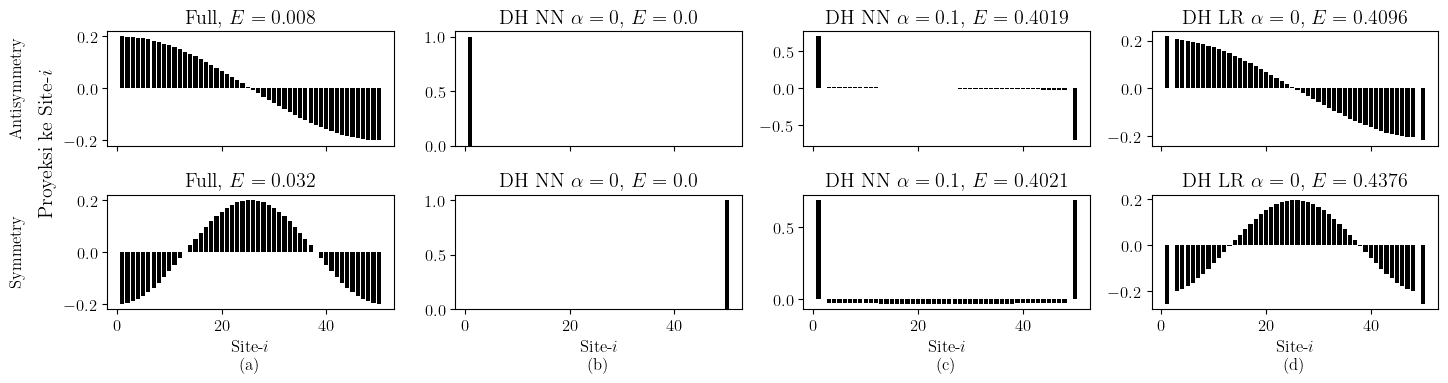

In [5]:
C = 1
a = 1 
nu = 10
B = 0
# alp = [0,1e-1,1e-2,1e-3,1e-4,]
alp = [1e-2]
N = 50
N_vals = np.arange(N,N+1)

H_long_full = HxLong(N,C,a,nu,B,0)
H_nn_dh = HxDHLong(N,C,a,100,B,0)
H_nn_dh_alp = HxDHLong(N,C,a,nu,B,1e-1)
H_long_lr = HxDHLong(N,C,a,3,B,0)

eigvals_nndh, eigvecs_nndh = np.linalg.eig(H_nn_dh)
eigvals_nndh_alp, eigvecs_nndh_alp = np.linalg.eig(H_nn_dh_alp)
eigvals_full, eigvecs_full = np.linalg.eig(H_long_full)
eigvals_lr, eigvecs_lr = np.linalg.eig(H_long_lr)

idx = np.argsort(eigvals_nndh)
eigvals_nndh = eigvals_nndh[idx]
eigvecs_nndh = eigvecs_nndh[:, idx]

idx1 = np.argsort(eigvals_nndh_alp)
eigvals_nndh_alp = eigvals_nndh_alp[idx1]
eigvecs_nndh_alp = eigvecs_nndh_alp[:, idx1]

idx2 = np.argsort(eigvals_full)
eigvals_full = eigvals_full[idx2]
eigvecs_full = eigvecs_full[:, idx2]

idx3 = np.argsort(eigvals_lr)
eigvals_lr = eigvals_lr[idx3]
eigvecs_lr = eigvecs_lr[:, idx3]

idx_range = range(1,3)
# idx_range = range(len(eigvals_nndh)*0,len(eigvals_nndh))
fig, ax = plt.subplots(2, 4, figsize=(15, 2*len(idx_range)), sharex=True)

for row, i in enumerate(idx_range):
    ax[row, 0].bar(
        1+np.arange(len(eigvecs_full[:, i])),
        eigvecs_full[:, i],
        color="black"
    )
    ax[row, 0].set_title(fr"Full, $E={eigvals_full[i]:.3f}$")
    ax[row, 1].bar(
        1+np.arange(len(eigvecs_nndh[:, i+1])),
        eigvecs_nndh[:, i+1],
        color="black"
    )
    ax[row, 1].set_title(fr"DH NN $\alpha=0$, $E={eigvals_nndh[i]:.1f}$")
    ax[row, 2].bar(
        1+np.arange(len(eigvecs_nndh_alp[:, i])),
        eigvecs_nndh_alp[:, i],
        color="black"
    )
    ax[row, 2].set_title(fr"DH NN $\alpha=0.1$, $E={eigvals_nndh_alp[i]:.4f}$")
    ax[row, 3].bar(
        1+np.arange(len(eigvecs_lr[:, i +2 ])),
        eigvecs_lr[:, i+2],
        color="black"
    )
    ax[row, 3].set_title(fr"DH LR $\alpha=0$, $E={eigvals_nndh_alp[i+2]:.4f}$")    

import string

for i, axi in enumerate(ax[1, :]):
    axi.set_xlabel(f'Site-$i$\n({string.ascii_lowercase[i]})',)
    # axi.set_xlabel(f'Site-$i$')

fig.supylabel("Proyeksi ke Site-$i$",x=0.055,y=0.62)
ax[0, 0].set_ylabel("Antisymmetry",labelpad=28)
ax[1, 0].set_ylabel("Symmetry",labelpad=28)

plt.tight_layout()
plt.savefig(f"eigvec_full_dh.pgf")
# plt.savefig(f"eigvec_full_dh_nu{nu}.png")
plt.show()
# print(eigvals_nndh)
done()

### Misc.

In [ ]:
C = 1/4
a = 1 
nu = 3
B = 1

N_vals = np.arange(501,1001)
nu_vals = np.arange(3,4)

dipole_full = comp(HxDipole, C, a, B)
dipole_dh = comp(HxDHDipole, C, a, B)
# dipole_full_plus = comp(HxDipole, C, a, B)
# dipole_dh_plus = comp(HxDHDipole, C, a, B)

# arr1 = np.array(dipole_dh)   
# arr2 = np.array(dipole_dh_plus)   

# arr = np.concatenate((arr1, arr2), axis=1)

In [ ]:
plt.figure(figsize=(10, 6))
plt.xlabel(r'$F$')
plt.ylabel(r'$N$')

# plt.plot(N_vals[1:], dipole_dh[0][1:], label=rf"Double-hole", color="black")
# plt.plot(np.arange(2,2+len(arr[0]))[1:], arr[0][1:], label=rf"Double-hole", color="black")
# plt.scatter(N_vals[0:], dipole_full[0][0:], label=rf"Complete",  color="black", facecolors="none",marker="D")


plt.ylim(0.9 - 1e-2,1 + 1e-2)
plt.legend()

plt.savefig("DipoleLikeHamiltonian.pgf")

misc. 2

In [ ]:
C = 1
a = 1 
nu = 3
B = 1

N_vals = np.arange(128,131)
# nu_vals = [1,2,3,5,10]
nu_vals = [10]

# Hxxx_full = comp(Hx, C, a, B)
Hxxx_dh = comp(HxDH, C, a, B)
done()
print(Hxxx_dh)

In [ ]:
N_vals = np.arange(1,1001)
nu_vals = [1,2,3,5,10]
Hxxx_dh = np.load("data/Hxxx_dh.npy")
Hxxx_full = np.load("data/Hxxx_full.npy")

plt.figure(figsize=(10, 6))
plt.xlabel(r'$N$')
plt.ylabel(r'$F$')

print((nu_vals))
print(len(Hxxx_dh))
print(len(Hxxx_full))

colors =plt.cm.tab20.colors
markers = ["D", "o", "s", "^", "v", "<", ">", "P", "X"]
for i, (nu, c) in enumerate(zip(nu_vals, colors)):
  # plt.scatter(N_vals, Hxxx_full[i], label=rf"nu = {nu}", facecolors="white", edgecolors=c)
  plt.plot(N_vals, Hxxx_dh[i], label=rf"nu = {nu}",color=c)

plt.xlim(0,100)
plt.legend()
plt.savefig("plot_FvsN_long.pgf")
# print(Hxxx_dh[-1][384:400])

In [ ]:
N_vals = np.arange(1,1001)
Hxxx_dh = np.load("data/Hxxx_dh.npy")
Hxxx_full = np.load("data/Hxxx_full.npy")

plt.figure(figsize=(10, 6))
plt.xlabel(r'$F$')
plt.ylabel(r'$N$')

colors =plt.cm.tab20.colors
nu_vals = np.arange(6,12)
# nu_vals = nu_vals[0:]
for i, (nu, c) in enumerate(zip(nu_vals, colors)):
  plt.plot(N_vals, Hxxx_dh[i], label=rf"nu = {nu}",color=c)

plt.legend()
print(Hxxx_dh[0][0:5])

In [ ]:
plt.figure(figsize=(10, 6))
plt.xlabel(r'$F$')
plt.ylabel(r'$N$')

colors =plt.cm.tab20.colors
for i, (nu, c) in enumerate(zip(nu_vals, colors)):
  plt.plot(N_vals, Hxxx_dh[i], label=rf"nu = {nu}",color=c)

plt.legend()
print(Hxxx_dh[-1][0:5])

In [ ]:
plt.figure(figsize=(10, 6))
plt.xlabel(r'$F$')
plt.ylabel(r'$N$')

colors =plt.cm.tab20.colors
for i, (nu, c) in enumerate(zip(nu_vals, colors)):
  plt.plot(N_vals, Hxxx_dh[i], label=rf"nu = {nu}",color=c)

plt.legend()
print(Hxxx_dh[-2][0:5])

# Constructing Heisenberg Hamiltonian

All sector $2^N \times 2^N$ space

In [ ]:
import numpy as np
import sympy as sp
from sympy.physics.matrices import msigma
from sympy.physics.quantum import TensorProduct
from scipy.linalg import expm

N = 4
J = sp.symbols('J', real=True)
B = sp.symbols('B', real=True)

sx = sp.Matrix(msigma(1))
sy = sp.Matrix(msigma(2))
sz = sp.Matrix(msigma(3))
I = sp.eye(2)

dim = 2**N
H = sp.zeros(dim)

def op_on_site(op, site, N):
    ops = []
    for i in range(N):
        if i == site:
            ops.append(op)
        else:
            ops.append(I)
    result = ops[0]
    for k in range(1, N):
        result = TensorProduct(result, ops[k])
    return sp.Matrix(result)

def two_site_op(op1, site1, op2, site2, N):
    ops = []
    for i in range(N):
        if i == site1:
            ops.append(op1)
        elif i == site2:
            ops.append(op2)
        else:
            ops.append(I)
    result = ops[0]
    for k in range(1, N):
        result = TensorProduct(result, ops[k])
    return sp.Matrix(result)

# Heisenberg interaction
for j in range(N - 1):
    H += -J * (
        two_site_op(sx, j, sx, j + 1, N)
        + two_site_op(sy, j, sy, j + 1, N)
        + two_site_op(sz, j, sz, j + 1, N)
    )

# Magnetic field
for i in range(N):
    H += -B * op_on_site(sz, i, N)

sp.pprint(H)

In [ ]:
t = 1
B=0
H_func = sp.lambdify((J, B), H, modules='numpy')
H_num = np.array(H_func(1,0), dtype=complex)
prop = expm(-1j * H_num * t)

vacuum = np.zeros((dim, 1), dtype=complex)
vacuum[0, 0] = 1

site = 1
ket_s = np.zeros((dim, 1), dtype=complex)
index = 2**(N - site)
ket_s[index, 0] = 1

alpha = 1/np.sqrt(2)
beta = 1/np.sqrt(2)

psi0 = alpha * vacuum + beta * ket_s
# print(psi0)

psi_t = prop @ psi0
print(psi_t)

Reduced $N \times N$ space

In [ ]:
import numpy as np
from scipy.linalg import expm

def Hx(N, J):
    H = np.zeros((N, N), dtype=complex)
    for i in range(N):
      if i == 0 or i == N - 1:
          H[i, i] = 2 * J
      else:
          H[i, i] = 4 * J
    for i in range(N - 1):
        H[i, i + 1] = -2 * J
        H[i + 1, i] = -2 * J

    return H

N = 1
J = 1
H = Hx(N,J)
print(Hx(N,J))

eigvals, eigvecs = np.linalg.eig(H)
# print(np.sort(eigvals))
for m in range(1, N+1):
    Em = 4*J * ( 1 - np.cos(np.pi * (m - 1) / N) )
    print(Em)

# print(eigvals)

# print(eigvecs)

V = np.zeros((N, N), dtype=complex)
for m in range(N):
    n = m+1
    a_m = np.where(n == 1, 1/np.sqrt(N), np.sqrt(2/N))
    for j in range(N):
        k = j+1
        V[j, m ] = a_m * np.cos(
                np.pi * (n -1) * (2*k - 1) / (2*N)
            )
    # print(n)
# print(V)


Constructing the propagator, evaluating $  f_N(t) = \bra{\mathbf{N}} e ^{-iHt }\ket{\mathbf{1}}  $

In [ ]:
t = 1
U = expm(-1j*H *t)
print(U)

fN = U[N-1,0]
absfN = np.abs(fN)
print(absfN)
F = 1/2 + np.real(fN) /3 + absfN**2 / 6
# print(F)



constructing $  f_N (t)  = \sum_{m=1 } ^N  \braket{\mathbf{r }  | \tilde{m}} e ^{-iE_mt}  \braket{\tilde{m }  | \mathbf{1}}\\$

In [ ]:
fN2 = 0.0 + 0.0j

for m in range(N):
    Em = eigvals[m]
    fr = eigvecs[N-1, m]
    fs = eigvecs[0, m]

    fN2 += fr * np.exp(-1j * Em * t ) * np.conj(fs)
print(np.abs(fN2))
F = 1/2 + np.real(fN2) /3 + np.abs(fN2)**2 / 6
# print(F)

constructing $ f_N(t) = \sum_{m=1 } ^N  \bra{\mathbf{N}} e ^{-iHt } \ket{\tilde{m }} \braket{\tilde{m }  | \mathbf{1}}$ 

In [ ]:
fN3 = 0.0 + 0.0j

for m in range(4):
    ket_m = eigvecs[:, m]
    bra_m = np.conj(eigvecs[:, m])
    bra_N = np.zeros((1, N), dtype=complex)    
    bra_N[0,N-1] = 1
    ket_1 = np.zeros((N, 1), dtype=complex)
    ket_1[0, 0] = 1

    fN3 += bra_N @ U @ ket_m * bra_m @ ket_1
  
fN3 = fN3[0]
print(fN3)
F = 1/2 + np.real(fN3) /3 + np.abs(fN3)**2 / 6
print(F)